# 1. Giriş ve Veri Yükleme (Data Loading)

Bu bölümde, bir ajanın hangi aracı (tool) seçmesi gerektiğini içeren bir veri kümesi oluşturuyoruz.

**Senaryo:** Kullanıcıdan gelen metinler (Prompt) ve ajanın seçmesi gereken doğru araç (Label).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Veri setini oluşturuyoruz
data = {
    'text': [
        "Laptop fiyatı ne kadar?", "Dolar kaç TL?", "Euro kaç para?", "Klavye ücreti nedir?",
        "Mouse ne kadar?", "100 dolar kaç euro eder?", "Ürün stokta var mı?", "Döviz çevir",
        "Bu cihazın maliyeti ne?", "Kur bilgisini getir", "Fiyat listesini göster", "TL çevirisi yap"
    ],
    'target_tool': [
        'price_tool', 'currency_tool', 'currency_tool', 'price_tool',
        'price_tool', 'currency_tool', 'price_tool', 'currency_tool',
        'price_tool', 'currency_tool', 'price_tool', 'currency_tool'
    ]
}

df = pd.DataFrame(data)
print("--- Veri Seti İlk 5 Satır ---")
print(df.head())

--- Veri Seti İlk 5 Satır ---
                      text    target_tool
0  Laptop fiyatı ne kadar?     price_tool
1            Dolar kaç TL?  currency_tool
2           Euro kaç para?  currency_tool
3     Klavye ücreti nedir?     price_tool
4          Mouse ne kadar?     price_tool


# 2. Veri Ön İşleme (Data Preprocessing)
Metin verilerini makine öğrenmesi modelinin anlayabileceği sayısal değerlere (vektörlere) dönüştürüyoruz.

In [3]:
# Metin temizleme
df['text'] = df['text'].str.lower()

# Veriyi Eğitim ve Test olarak ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target_tool'], test_size=0.2, random_state=42)

# TF-IDF Vektörleştirme (Kelimeleri matematiksel ağırlıklara dönüştürür)
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Eğitim veri boyutu: {X_train_tfidf.shape}")

Eğitim veri boyutu: (9, 24)


# 3. Model Kurulumu ve Eğitim Süreci (Model Setup & Training)
Ajanın "Hangi tool'u çağırmalıyım?" kararını verecek olan sınıflandırma modelini eğitiyoruz.

In [4]:
# Model olarak Naive Bayes seçiyoruz
model = MultinomialNB()

# Eğitim süreci
model.fit(X_train_tfidf, y_train)
print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


# 4. Sonuçların Gösterimi ve Görselleştirme (Evaluation)
Modelin (Ajanın beyninin) ne kadar doğru karar verdiğini test ediyoruz.

Model Doğruluk Oranı (Accuracy): %66.66666666666666


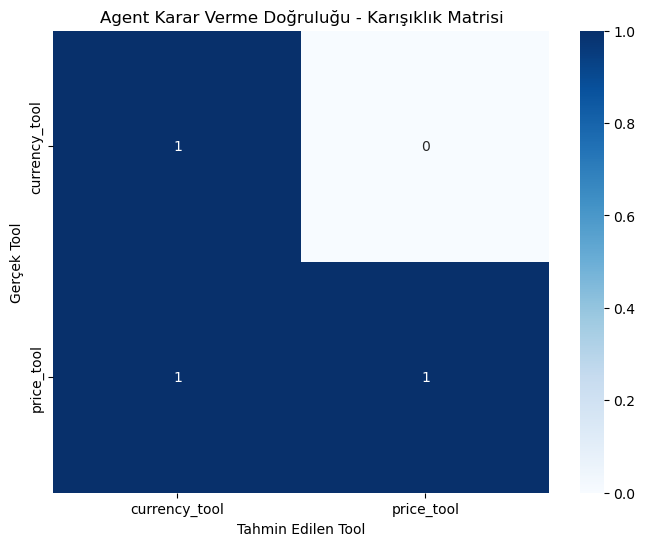

In [8]:
# Tahmin yapma
y_pred = model.predict(X_test_tfidf)

# Başarı metrikleri
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı (Accuracy): %{accuracy * 100}")

# Karışıklık Matrisi (Confusion Matrix) Görselleştirme
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Tahmin Edilen Tool')
plt.ylabel('Gerçek Tool')
plt.title('Agent Karar Verme Doğruluğu - Karışıklık Matrisi')
plt.show()

# 5. Uygulama: Tool-Calling Agent Entegrasyonu
Eğittiğimiz modeli kullanarak gerçek bir tool-calling simülasyonu yapıyoruz.

In [7]:
def call_price_tool(item):
    return f"[*] {item} için fiyat sorgusu yapıldı: 1500 USD."

def call_currency_tool(amount):
    return f"[*] Kur çevrimi yapıldı: {amount * 32} TL."

def simple_agent(user_input):
    # 1. Adım: Ön İşleme
    processed_input = tfidf.transform([user_input.lower()])
    
    # 2. Adım: Tahmin (Karar Verme)
    decision = model.predict(processed_input)[0]
    
    # 3. Adım: Aksiyon (Tool Execute)
    if decision == 'price_tool':
        return call_price_tool(user_input)
    else:
        return call_currency_tool(100) # Örnek tutar

# Test promtu
print(simple_agent("Yeni bir laptopun fiyatı ne kadar?"))

[*] Yeni bir laptopun fiyatı ne kadar? için fiyat sorgusu yapıldı: 1500 USD.
